In [ ]:
import os

import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt


import nerf_model as nerf
from dataset import NeRF_Dataset
from utils import random_rotation, look_at_rotation

## Load small dataset $\mathcal{T}$
We load the small dataset we train NeRF on, then we display a chosen test- image. Note that this test-image is not used during training.
Our dataset has the following properties
* our scenes can be contained in a ball $B_r(0)$ with $r=2$
* we only sample from our rays within this ball


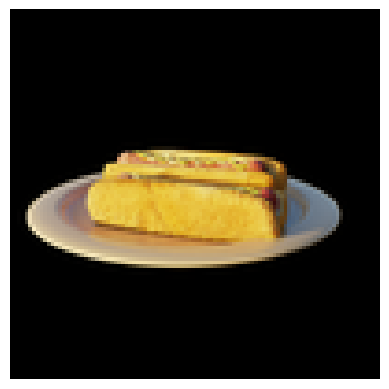

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = NeRF_Dataset("data/hotdog_data/hotdog.npz")

# For all our scenes our object is enclosed in a ball at the origin with radius 2
SCENE_RADIUS = 2

def show(image, permutation=(0,1,2)):
    grid_img = torchvision.utils.make_grid(image, nrow=5)
    plt.imshow(grid_img.permute(permutation))
    plt.axis('off')
    plt.show()


def get_thresholds(r):
    diff = r - SCENE_RADIUS
    tn = diff
    tf = diff + 2*SCENE_RADIUS

    return tn, tf

images = torch.from_numpy(dataset.images).to(device)
focal_length = torch.from_numpy(dataset.focal_length).to(device)
poses = torch.from_numpy(dataset.poses).to(device)

height, width = images.shape[1:3]

testimg = images[99, ..., :3]
testpose = poses[99]

translation = poses[:, :3,3]
center = torch.zeros(3).to(device)
diff = center - translation

n = torch.norm(diff, p=2, dim=1)
radius = torch.mean(n)

show(images[99].cpu())

In [4]:
dataset.__len__()

100

#### Display the first 10 images form the dataset

In [ ]:
for i in range(0, 10):
    show(images[i].cpu())

## Train NeRF


In [ ]:
num_encoding_functions = 6
encode = lambda x: nerf.positional_encoding(x, num_encoding_functions=num_encoding_functions)
depth_samples_per_ray = 228
lr = 1e-3
epochs = 100
display_every = 100

# load pretrained checkpoint
#model = nerf.TinyNerfModel().to(device)
#model.load_state_dict(torch.load("Chair.npz"))
#model.eval()

model = nerf.TinyNerfModel(num_encoding_functions=num_encoding_functions)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
losses = []
near_thresh, far_thresh = get_thresholds(radius)

/home/d/dziri/venvs/jlab/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


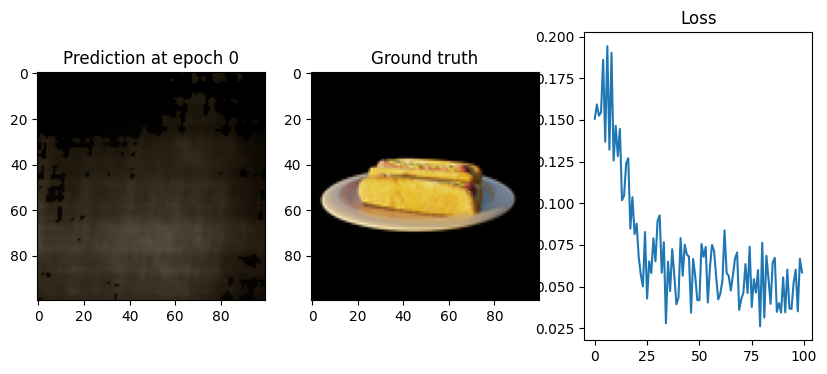

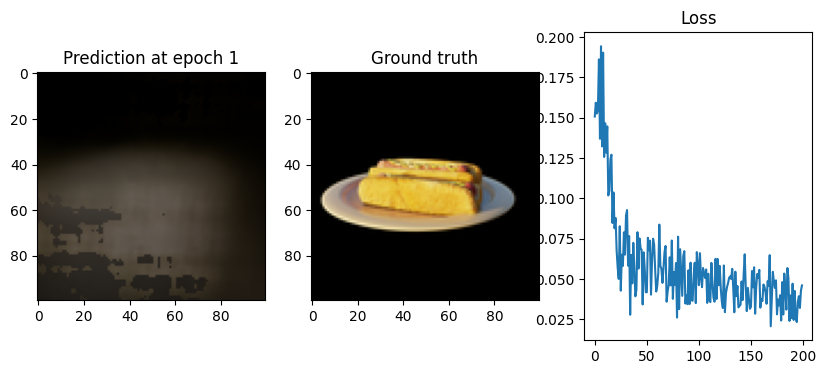

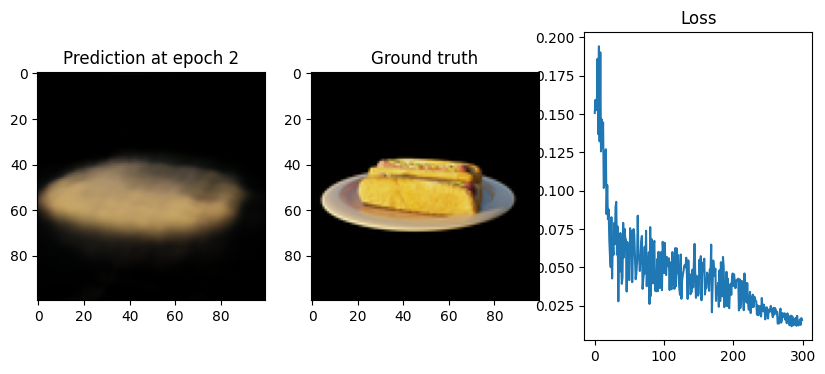

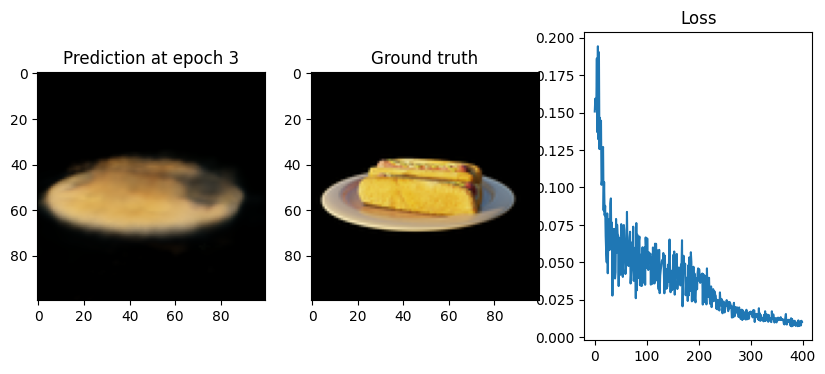

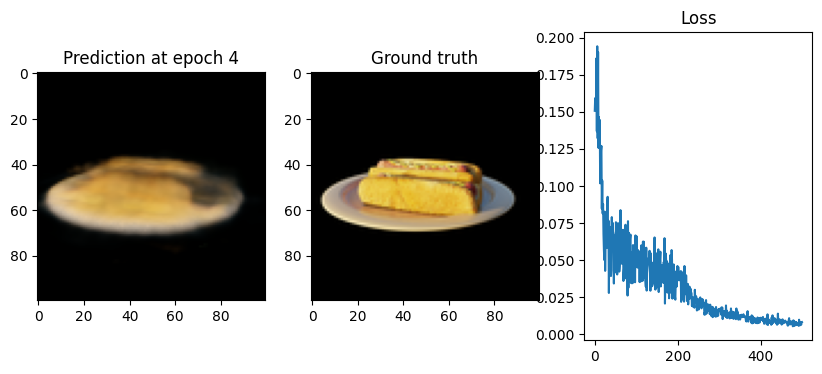

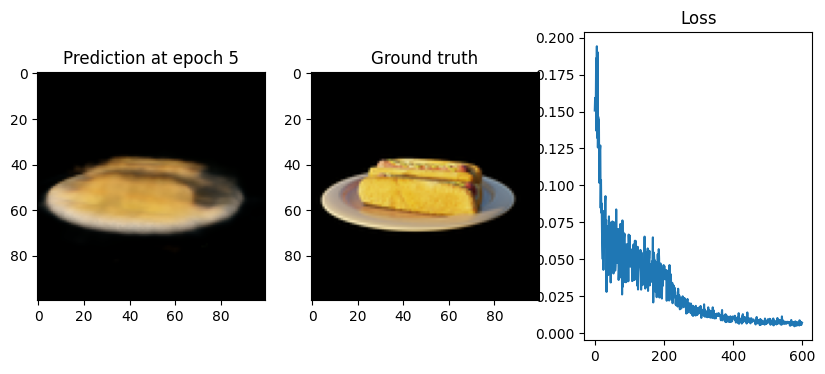

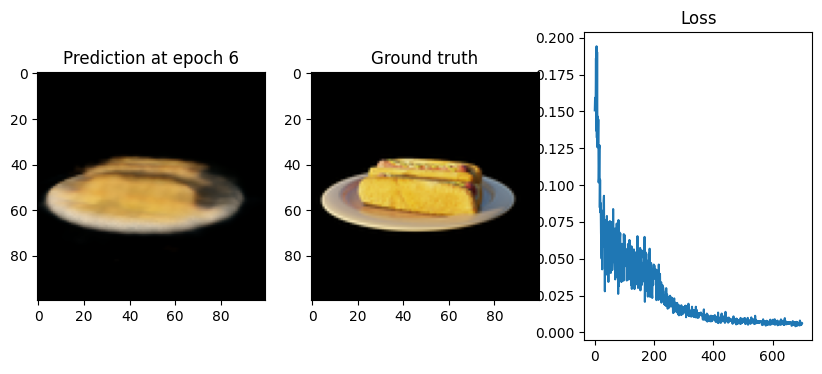

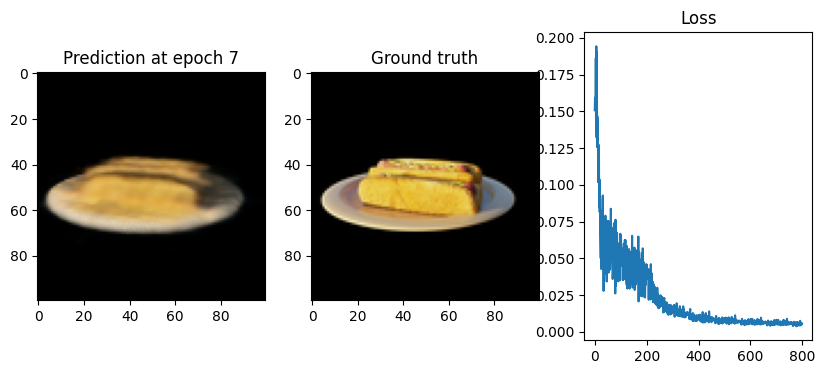

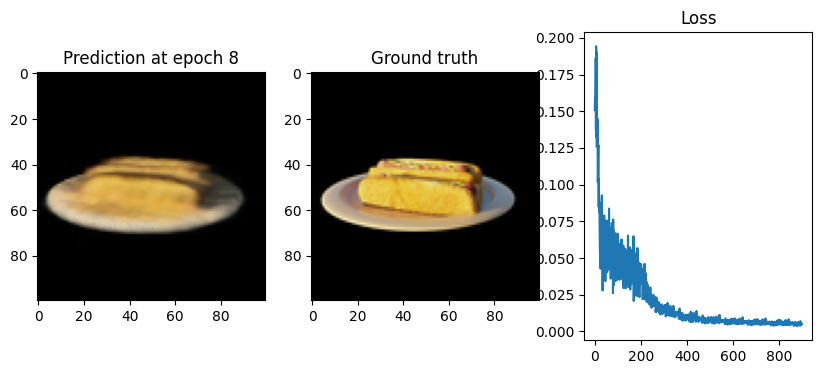

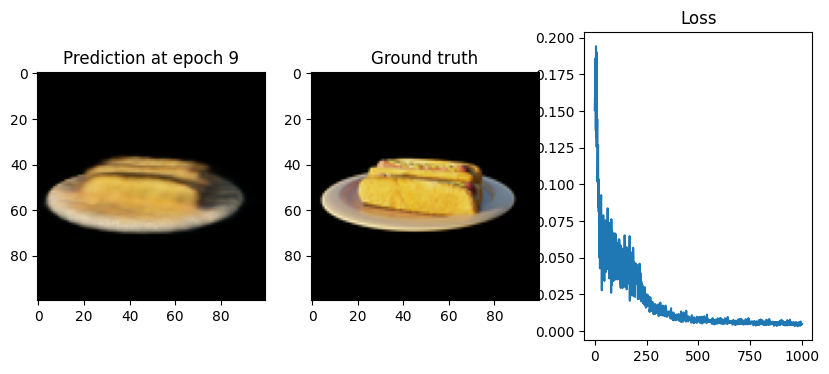

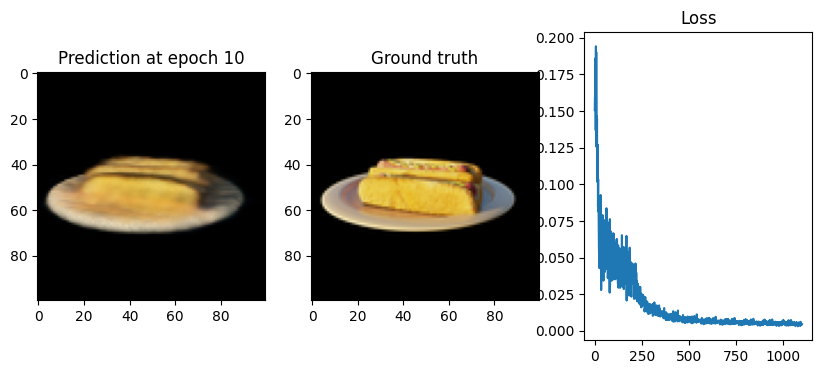

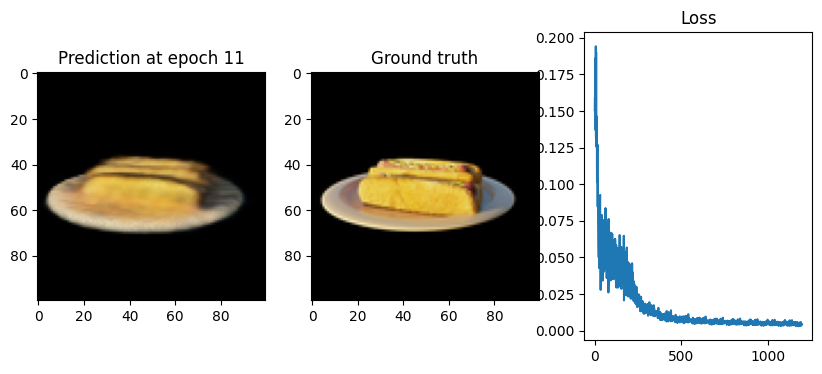

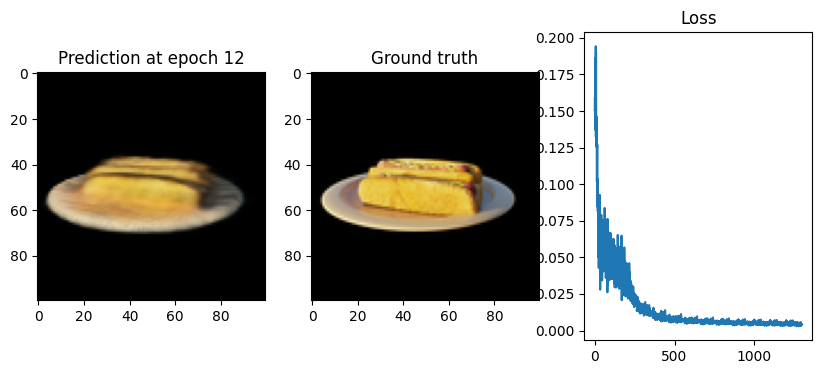

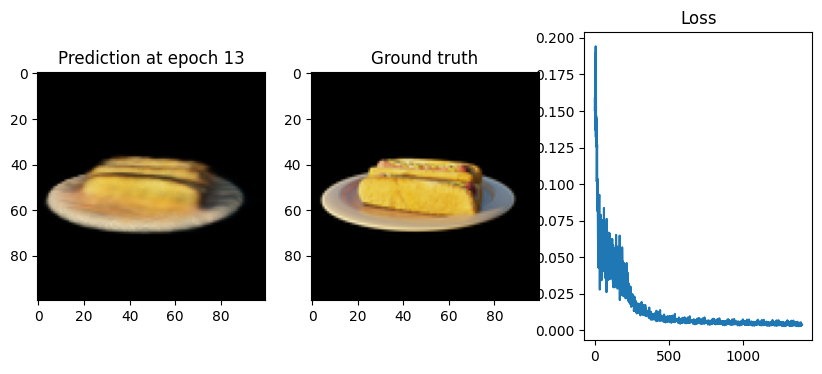

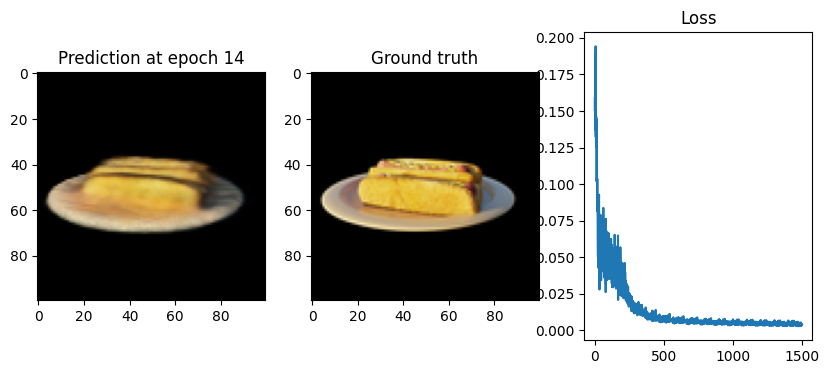

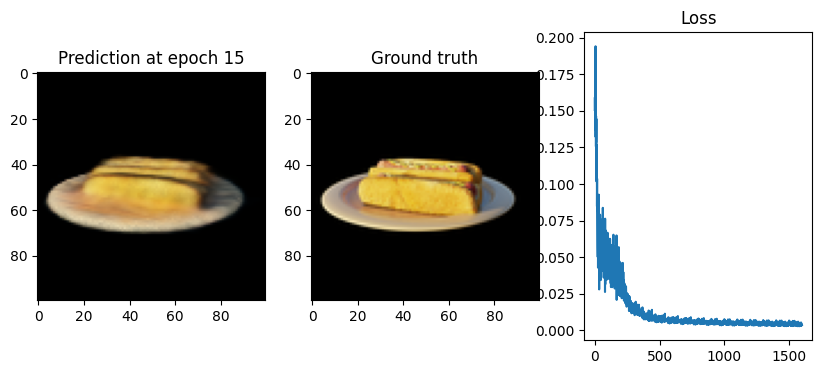

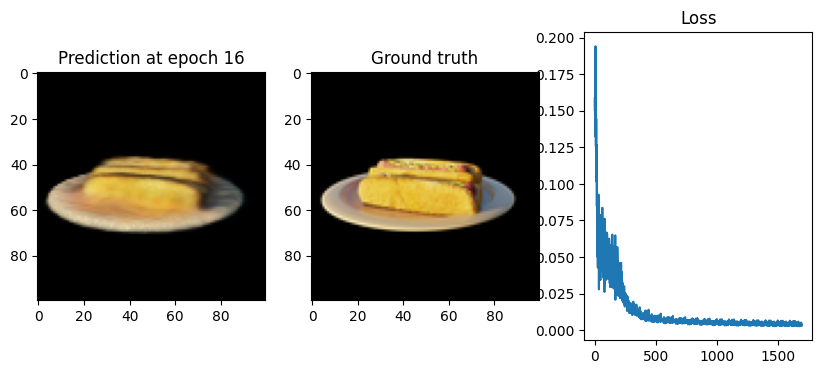

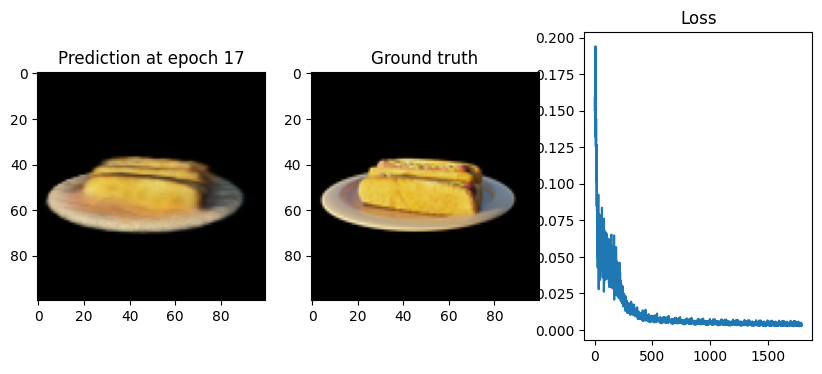

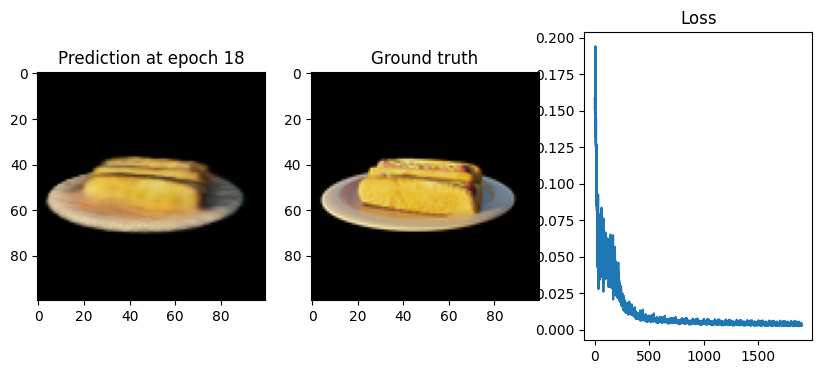

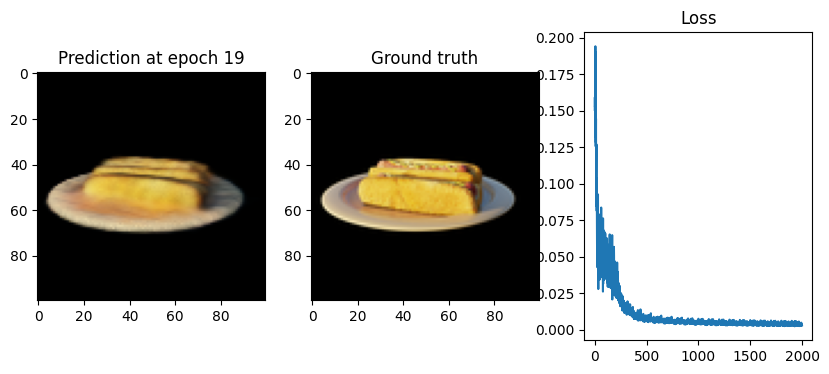

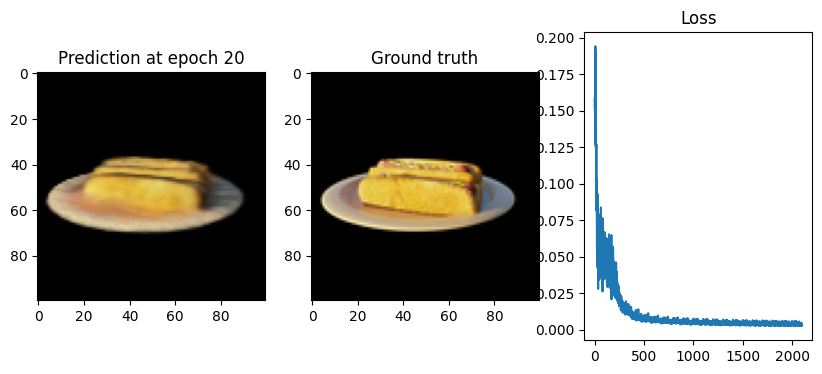

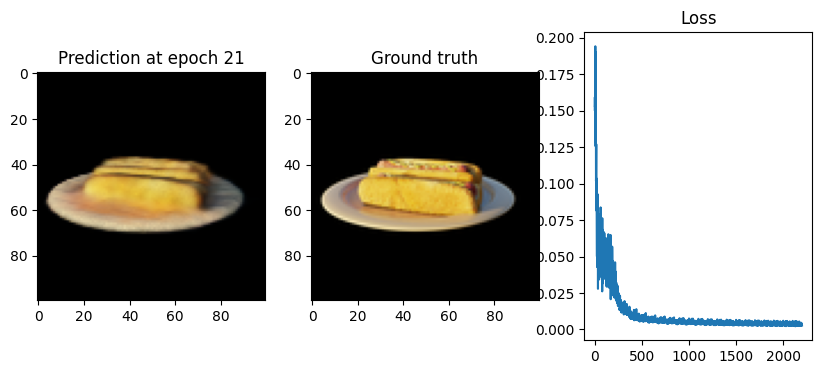

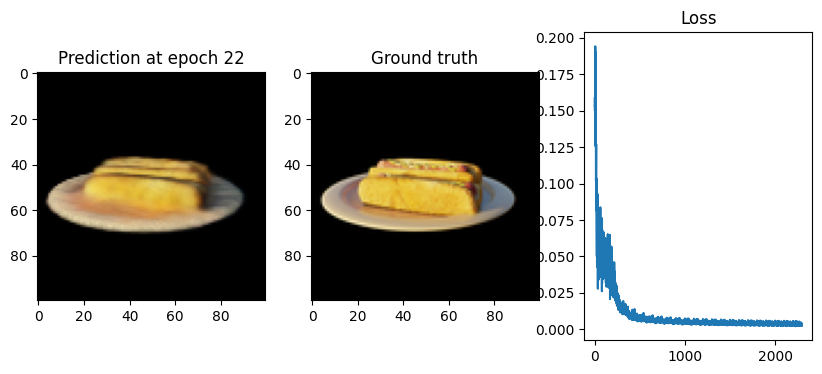

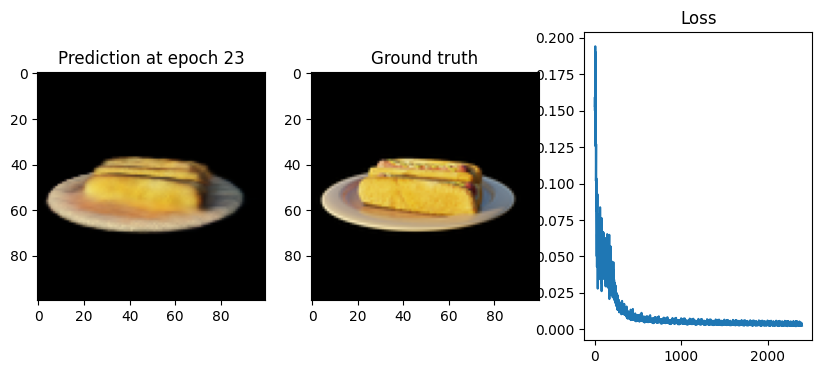

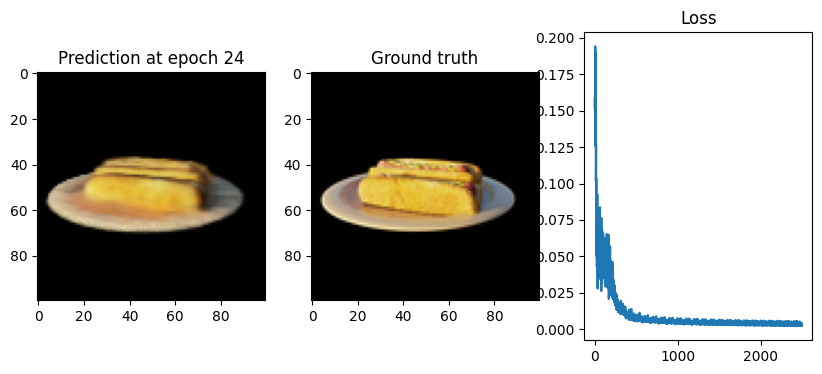

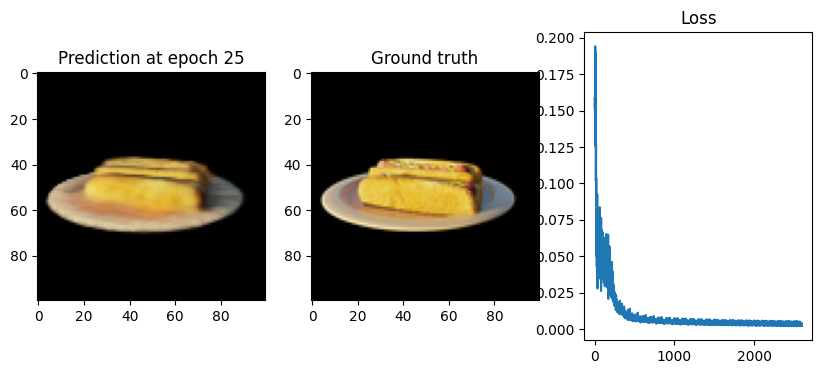

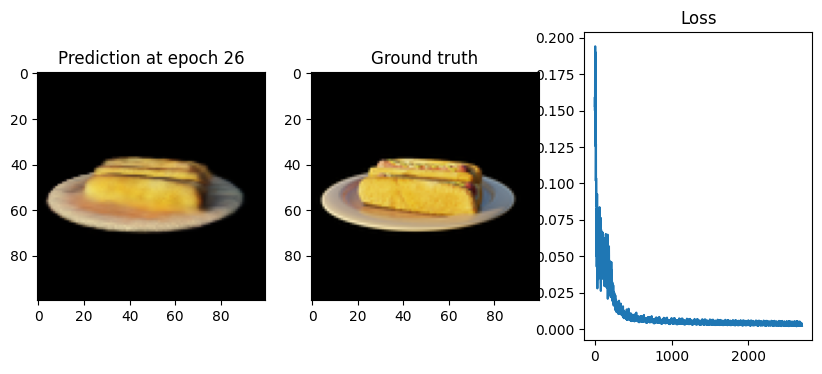

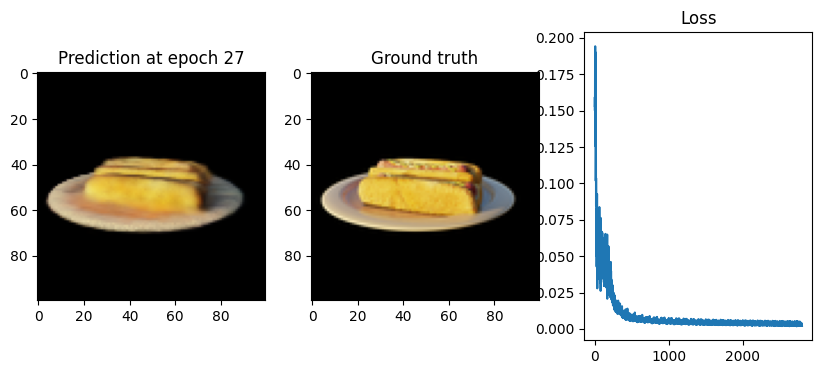

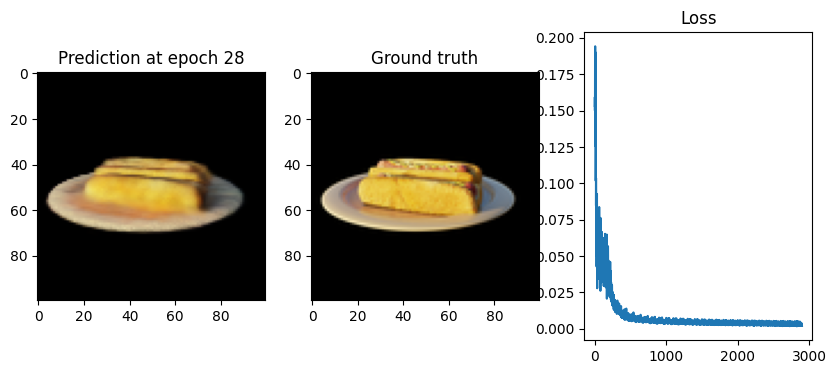

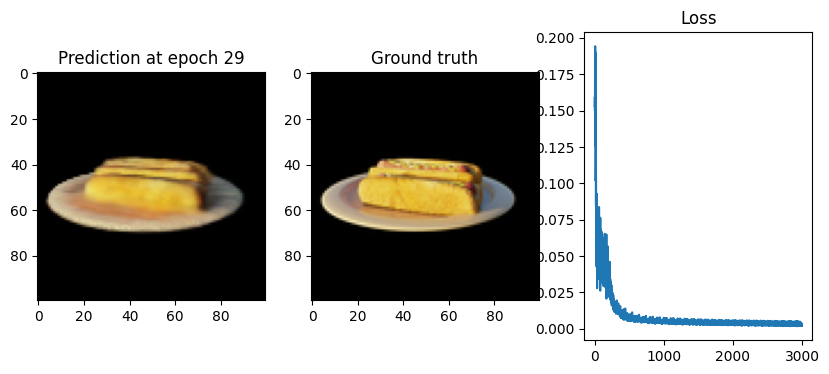

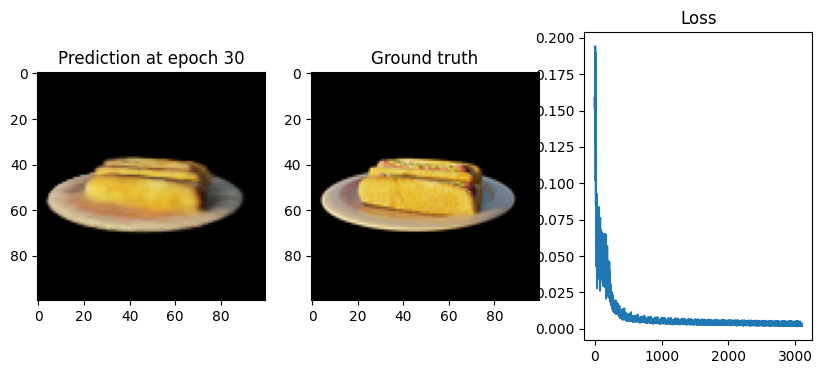

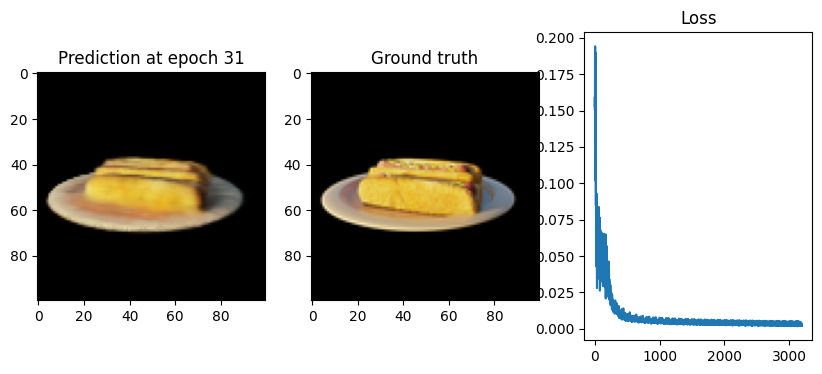

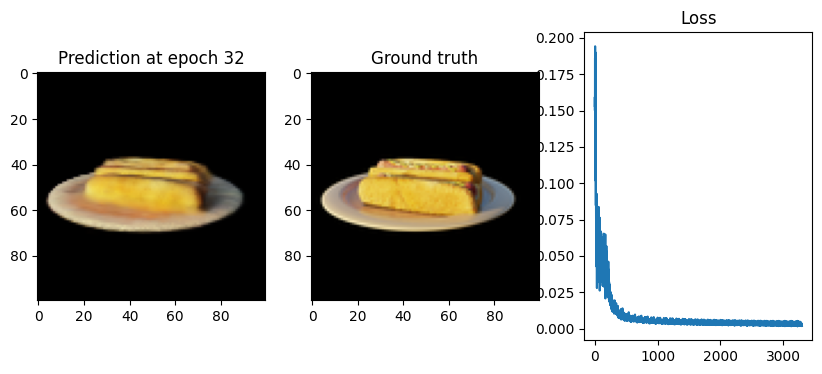

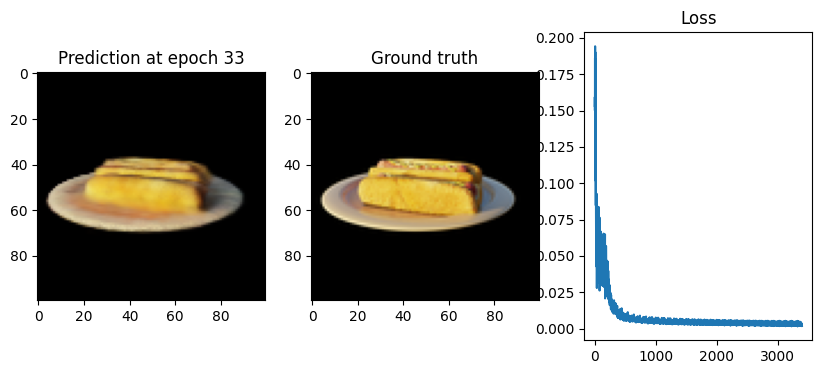

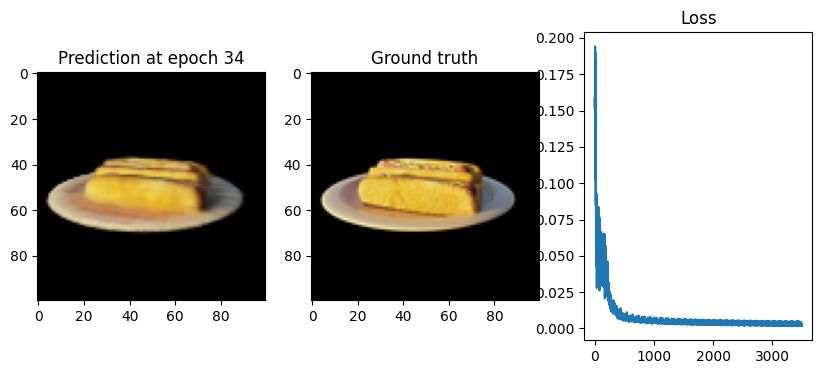

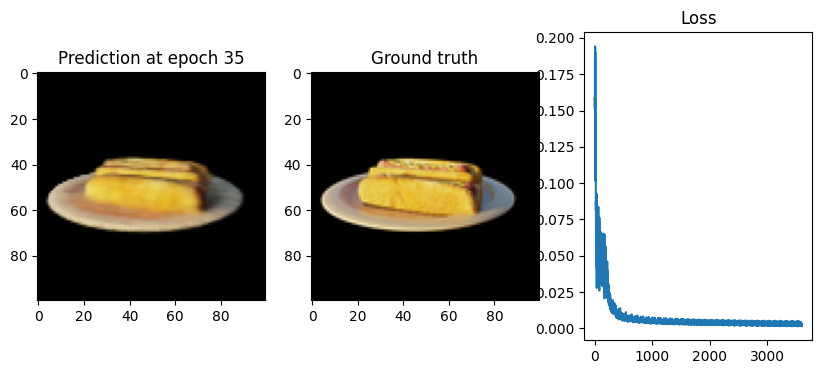

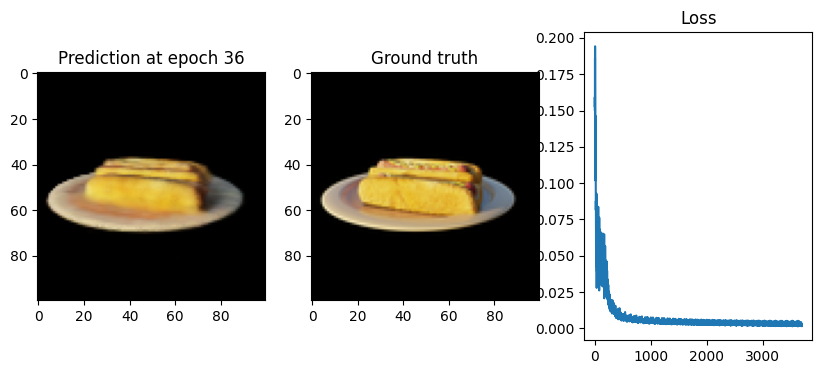

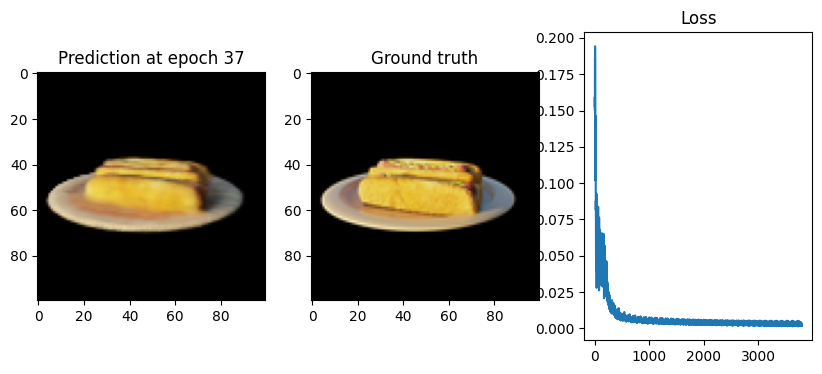

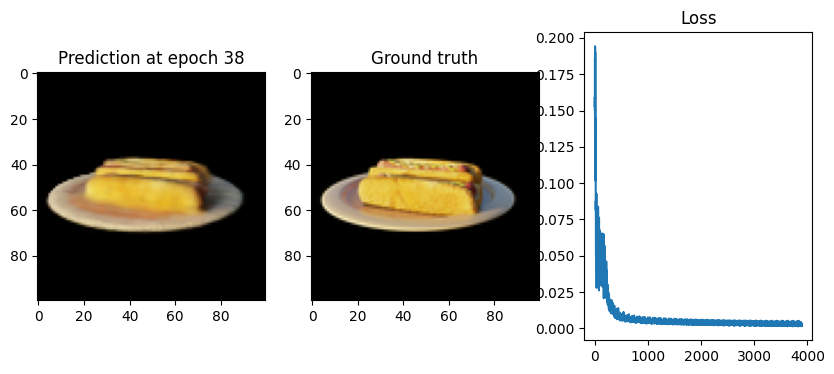

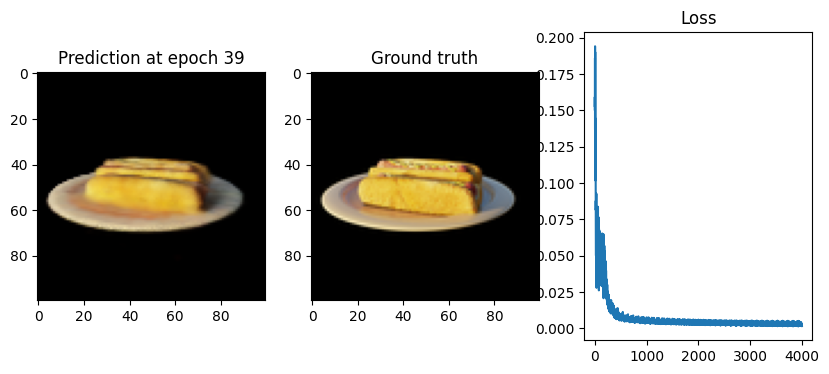

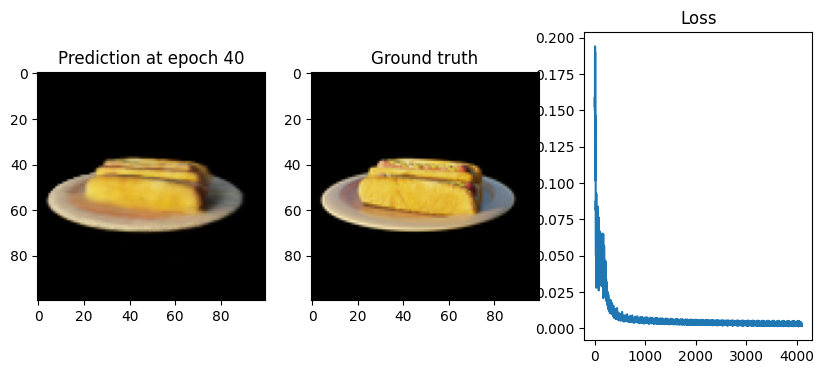

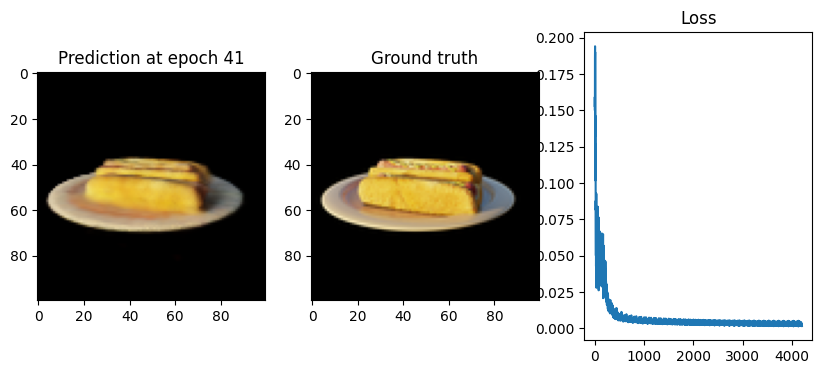

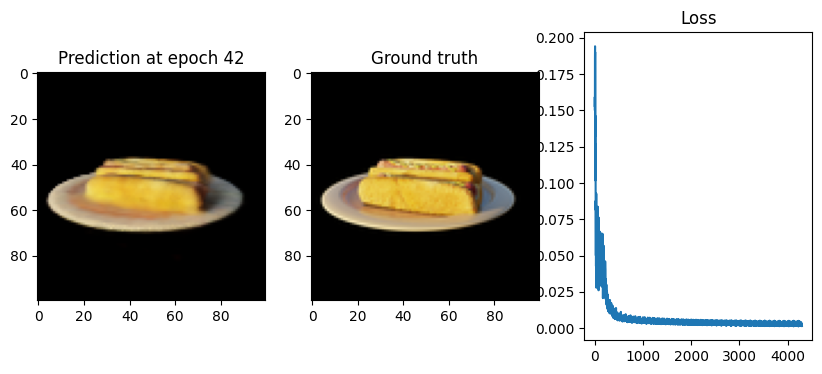

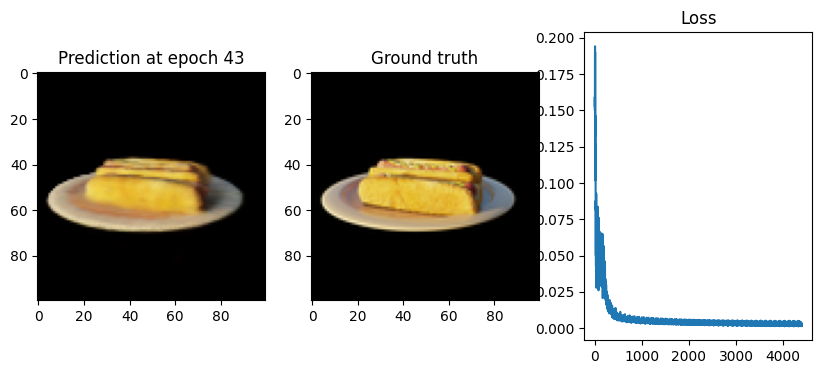

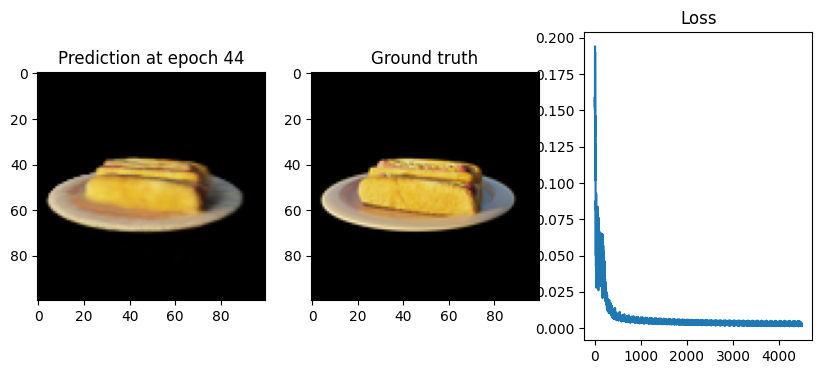

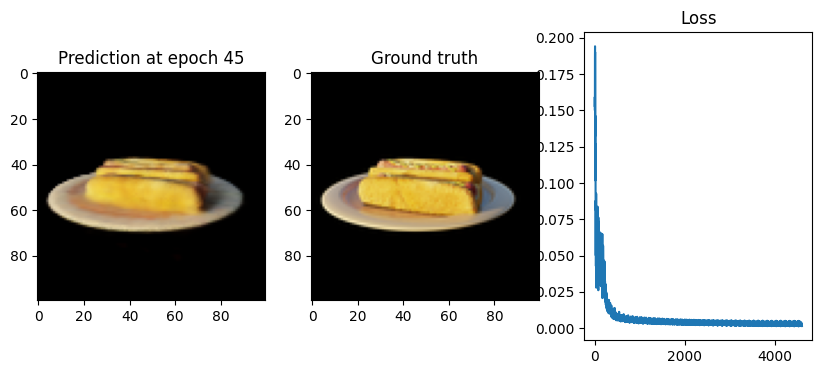

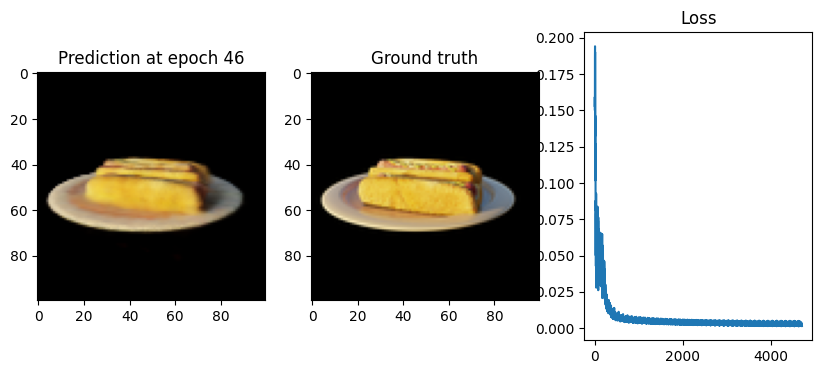

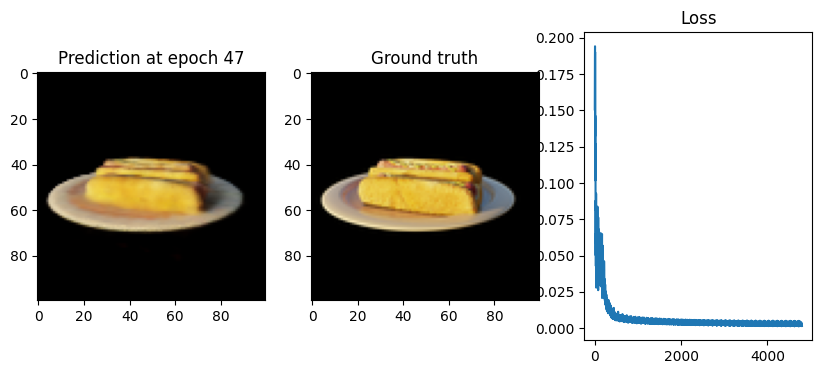

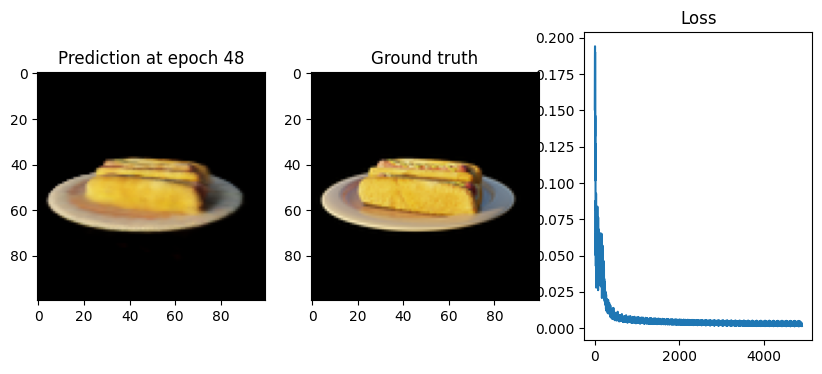

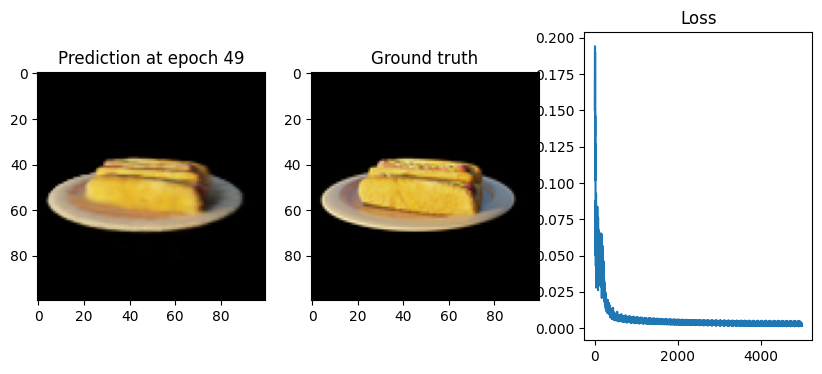

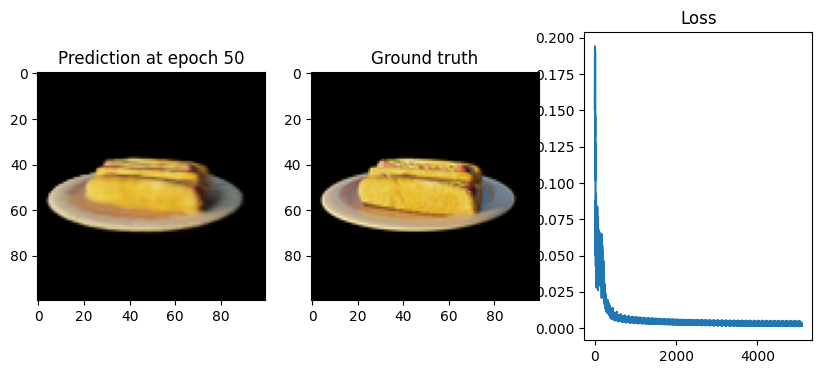

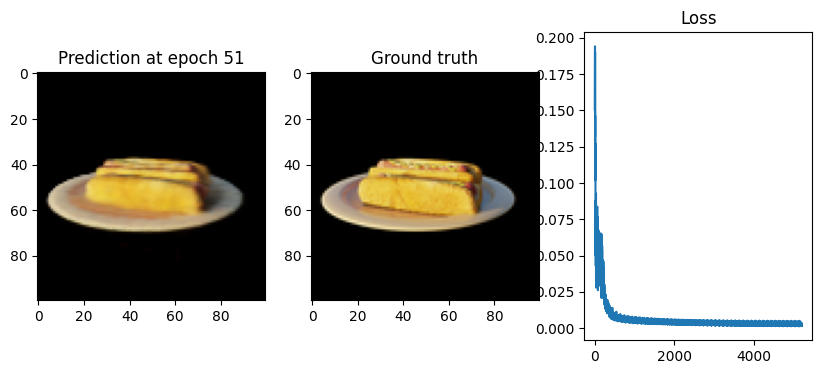

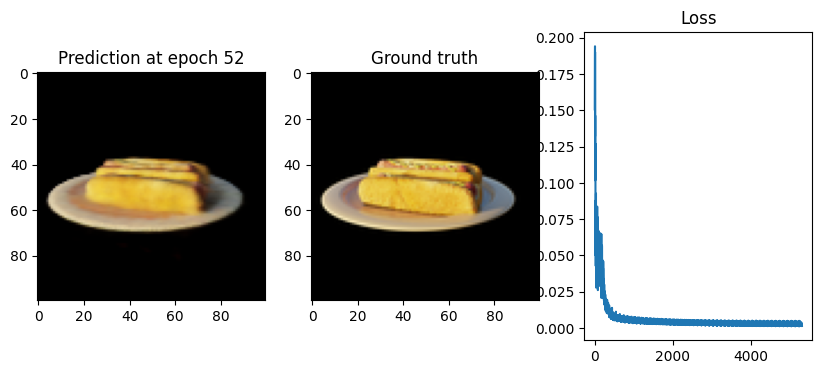

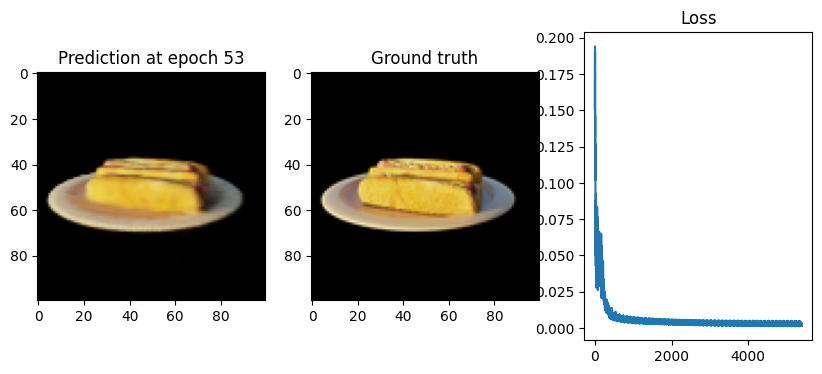

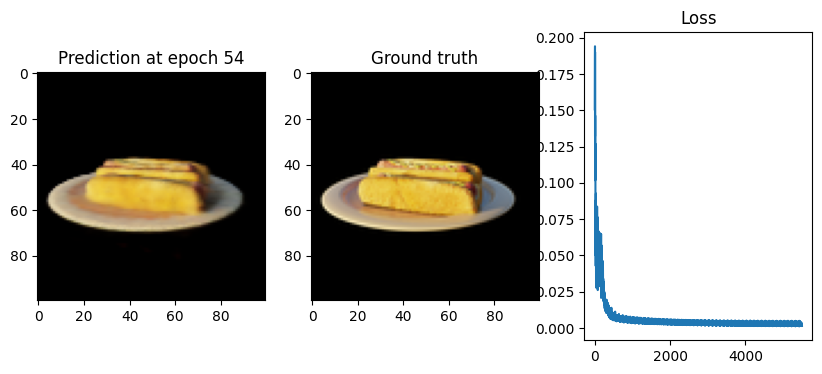

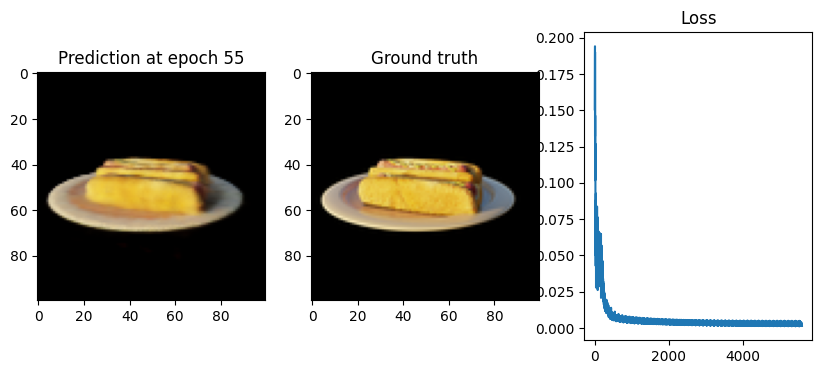

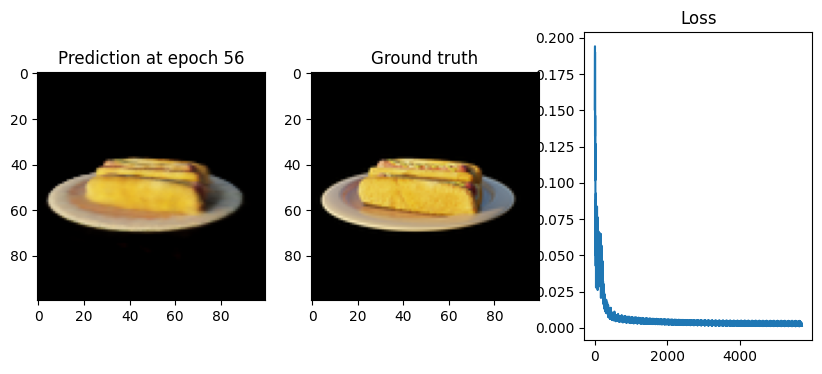

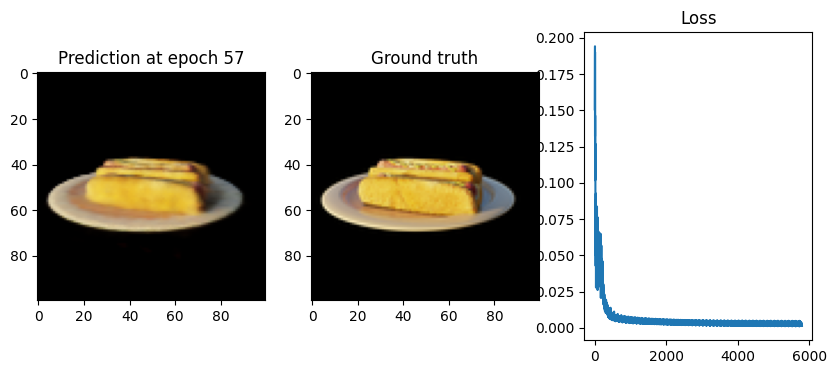

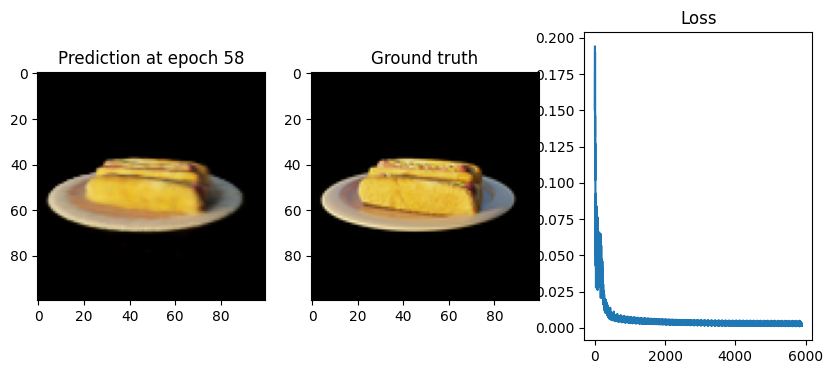

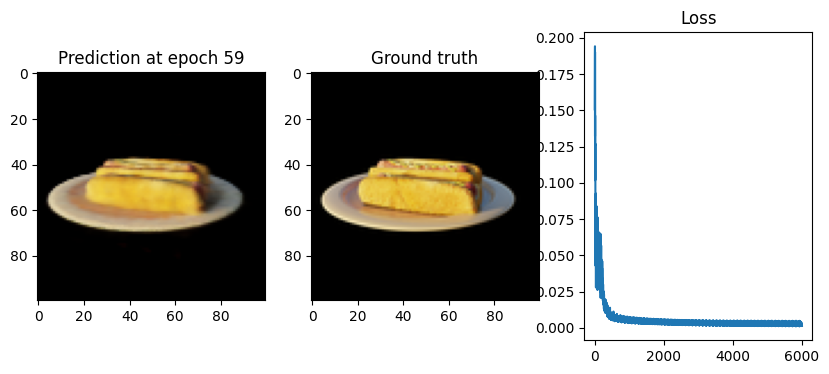

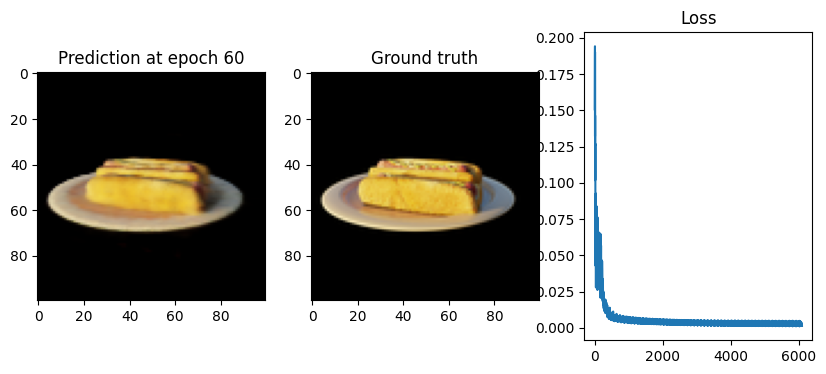

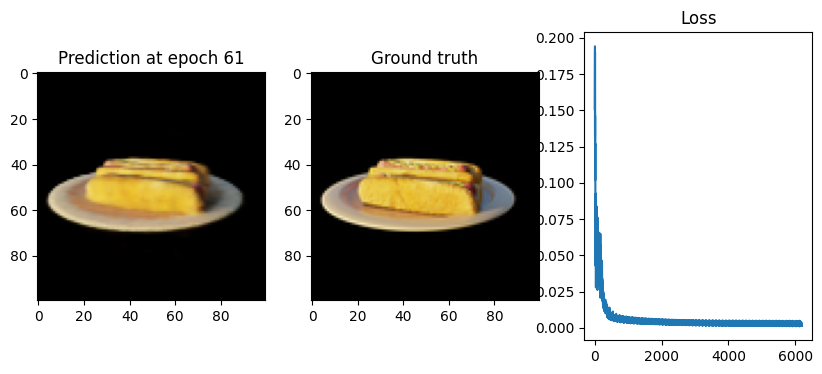

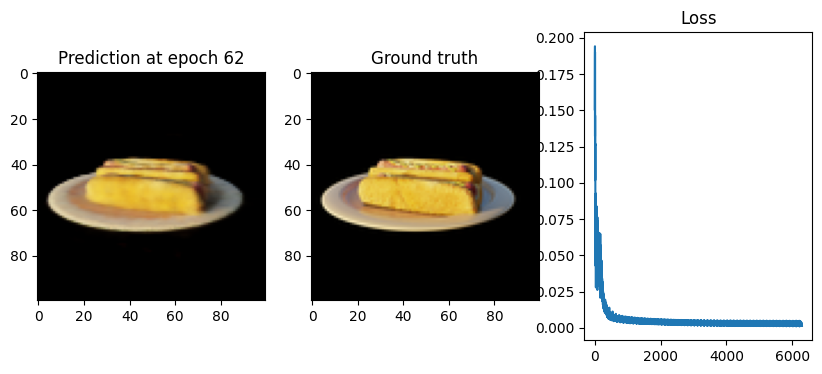

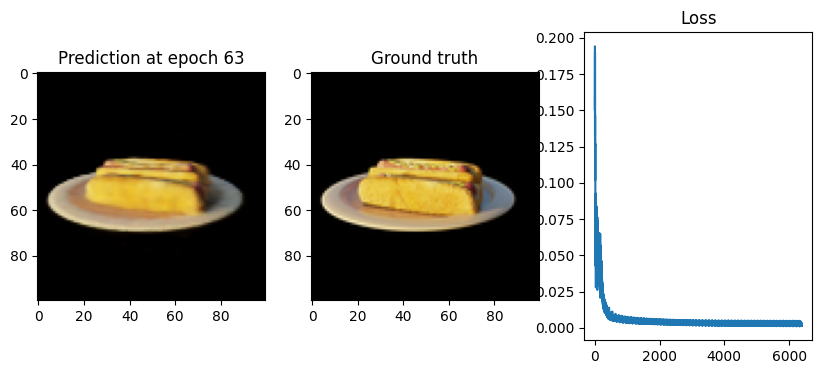

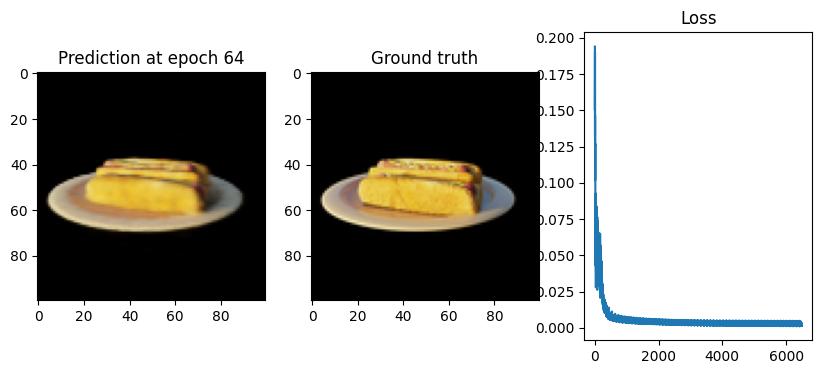

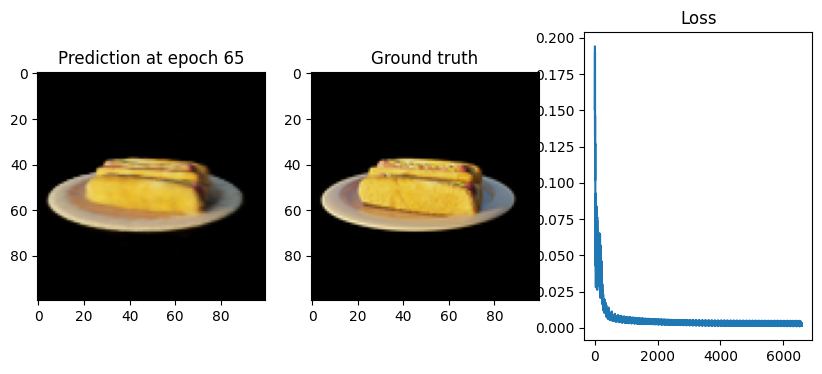

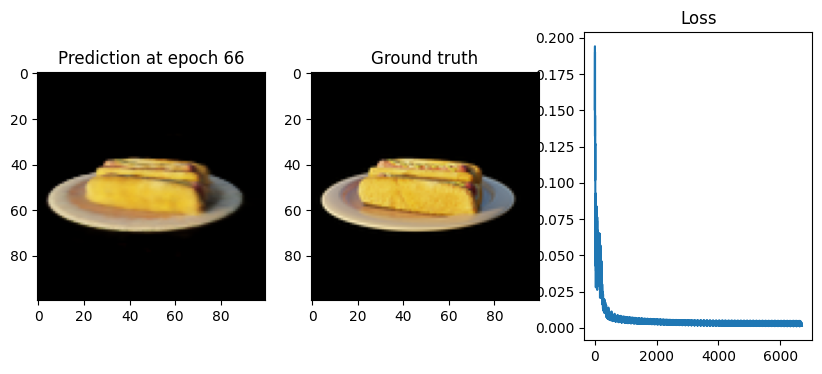

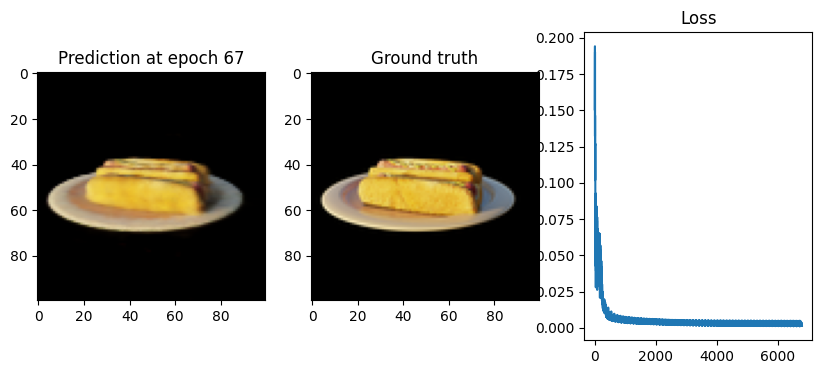

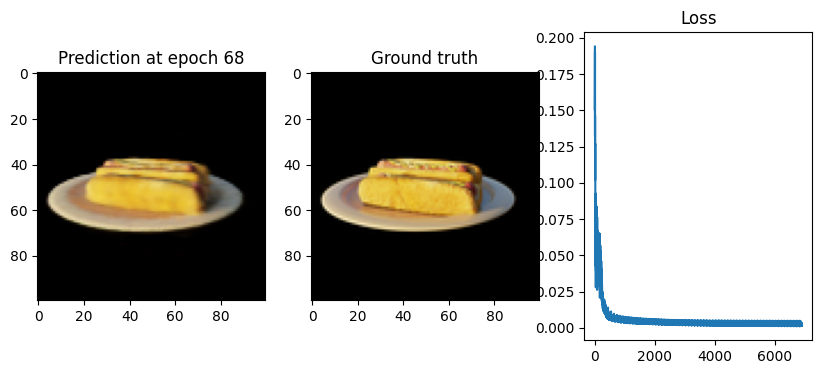

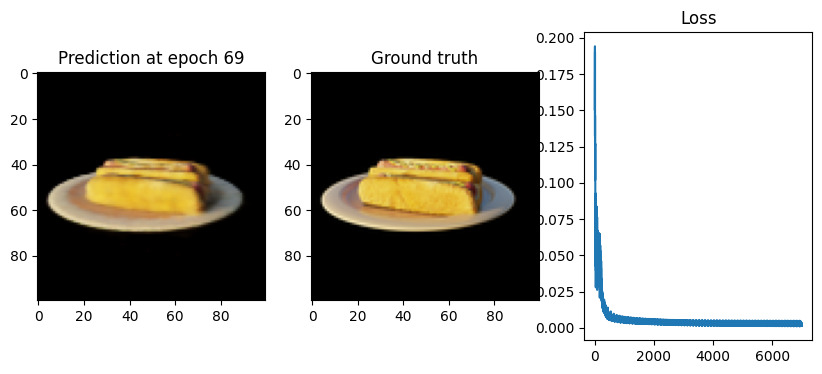

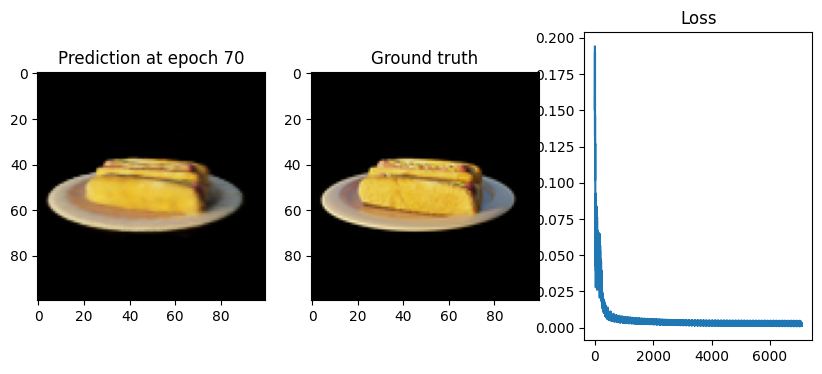

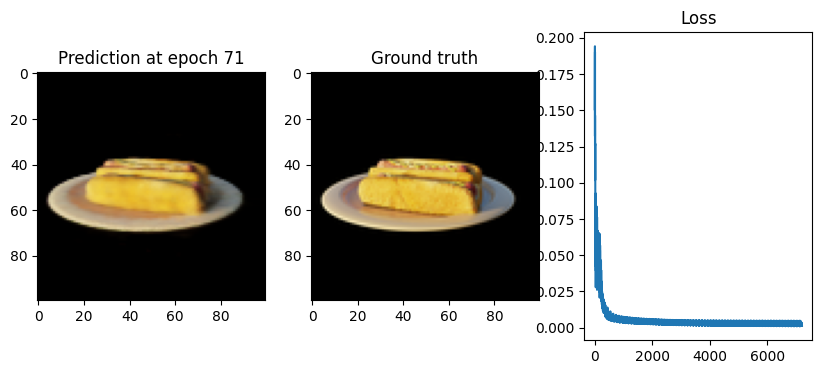

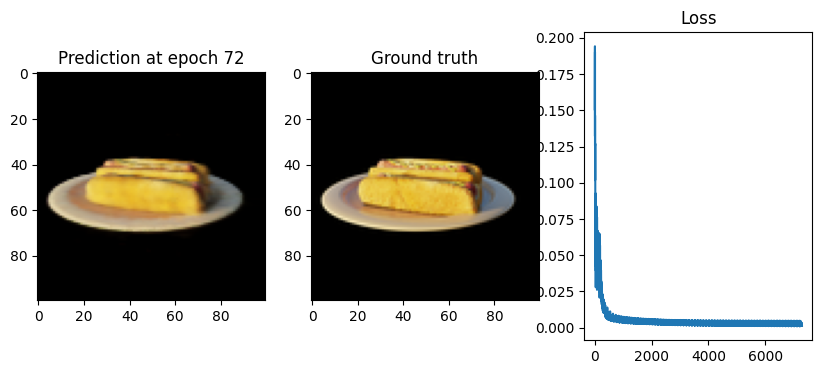

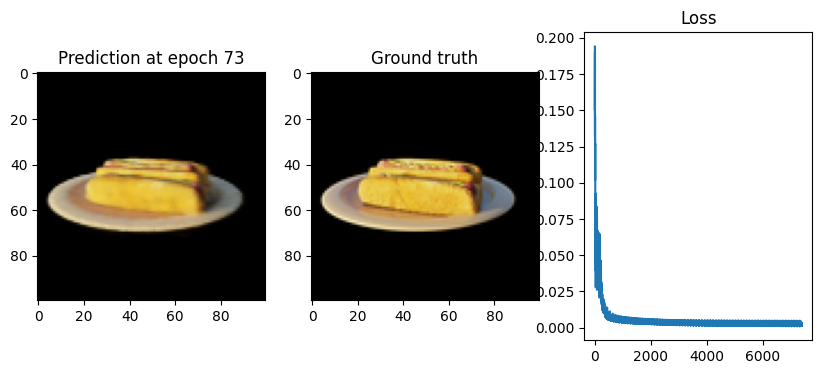

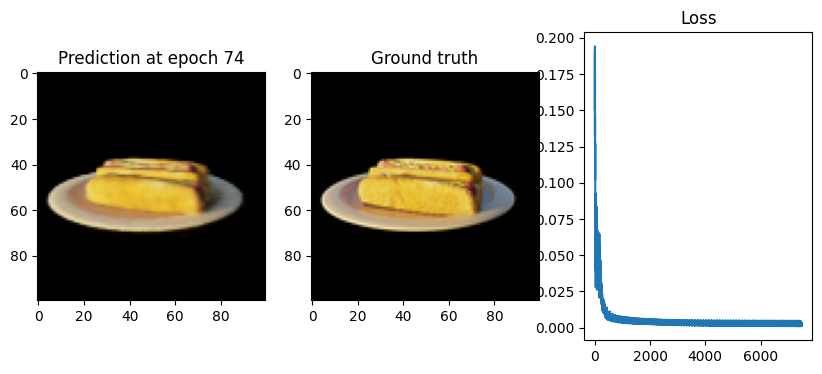

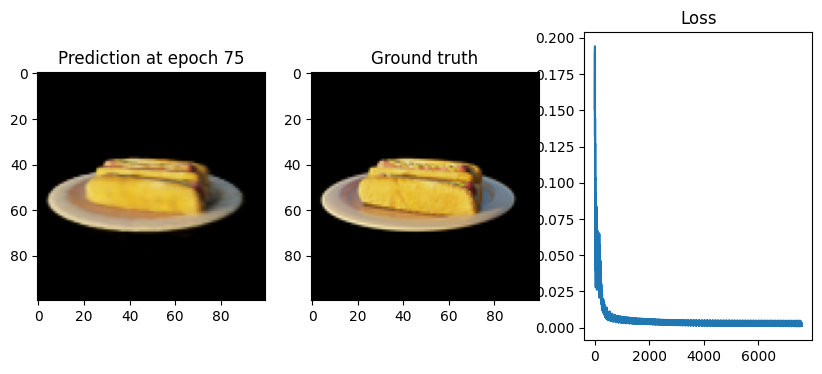

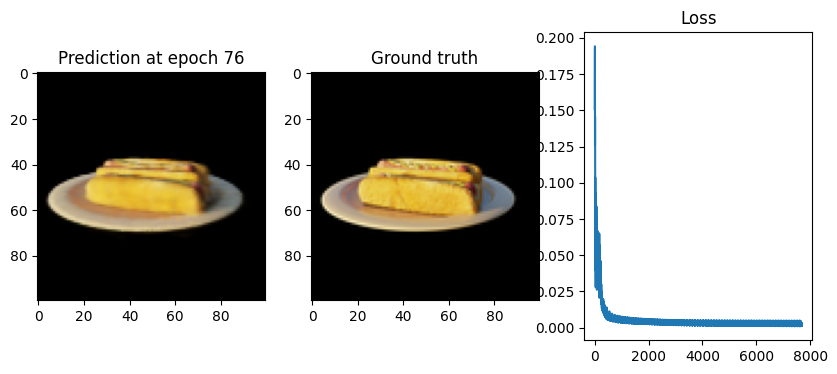

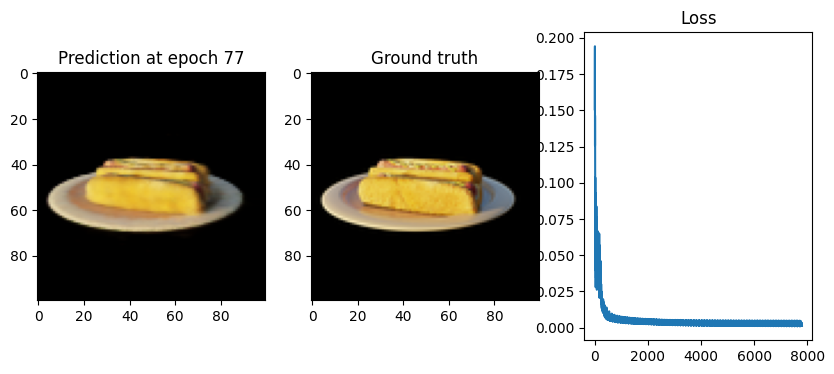

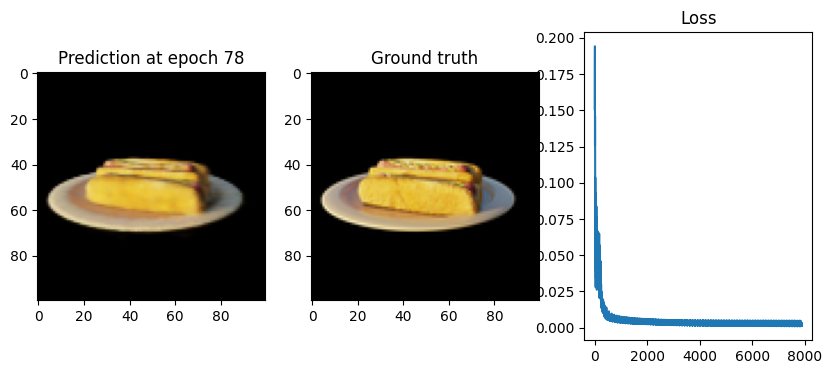

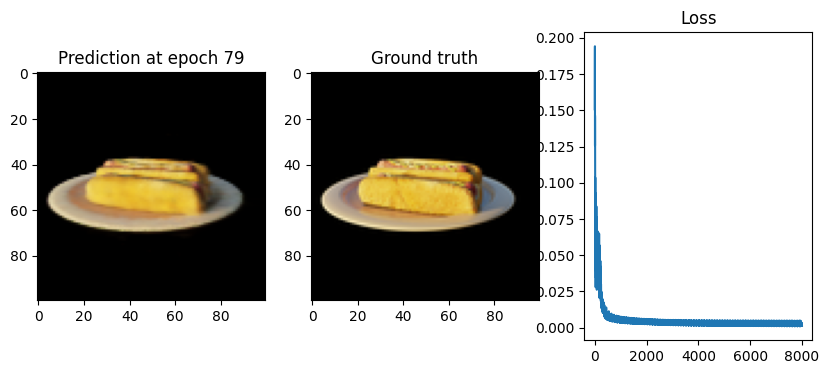

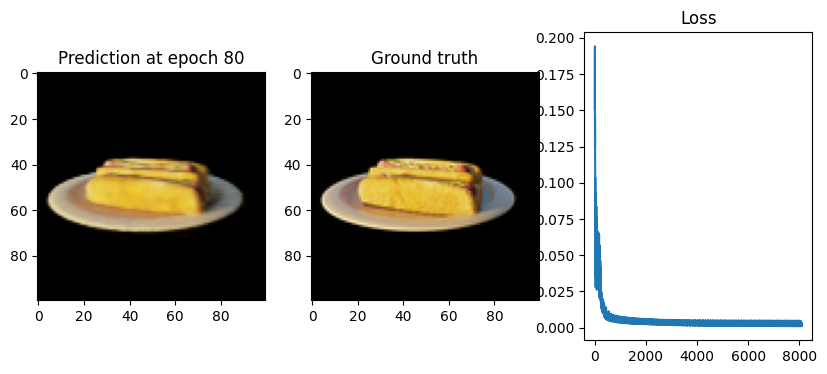

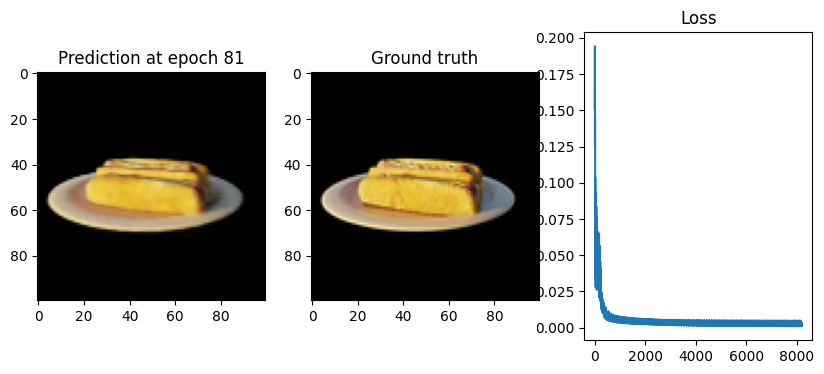

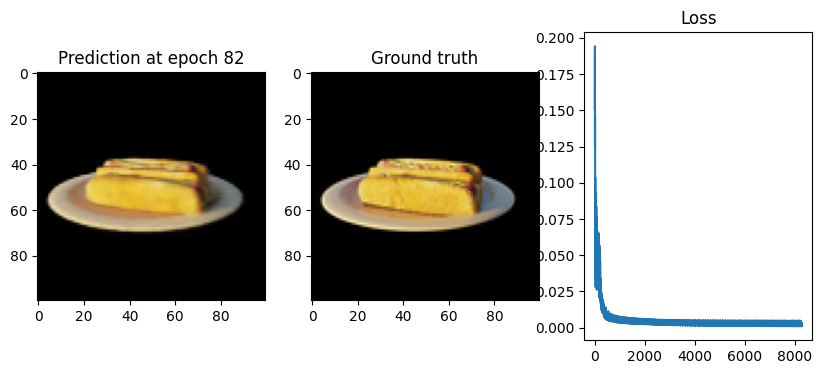

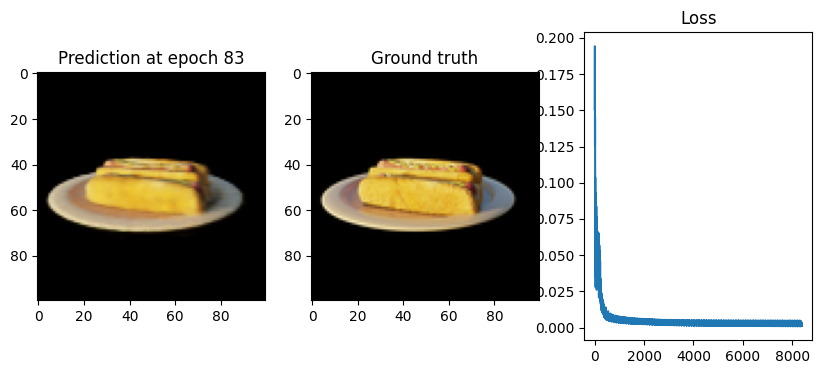

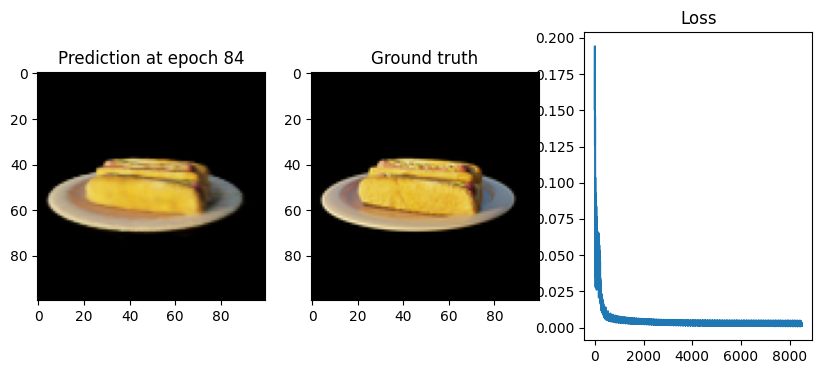

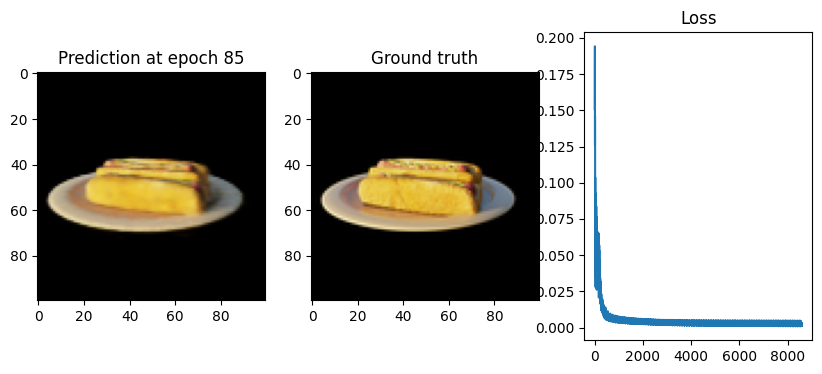

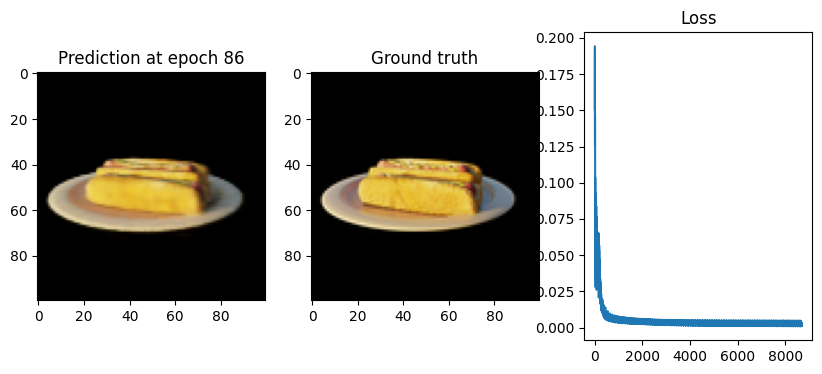

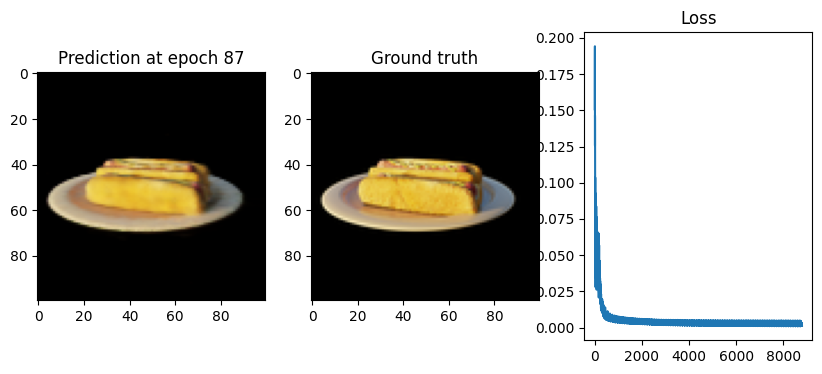

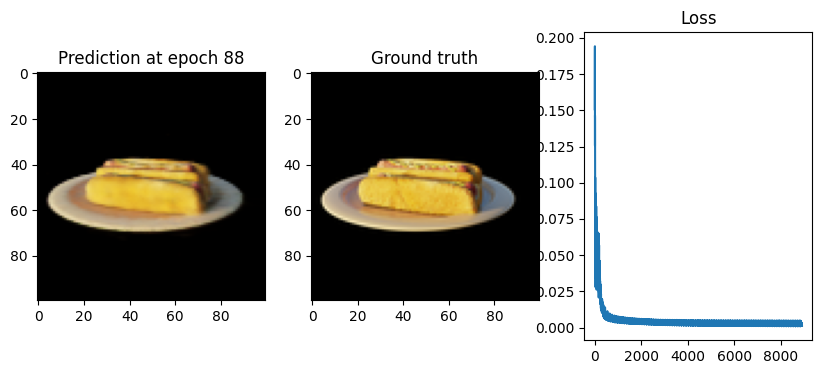

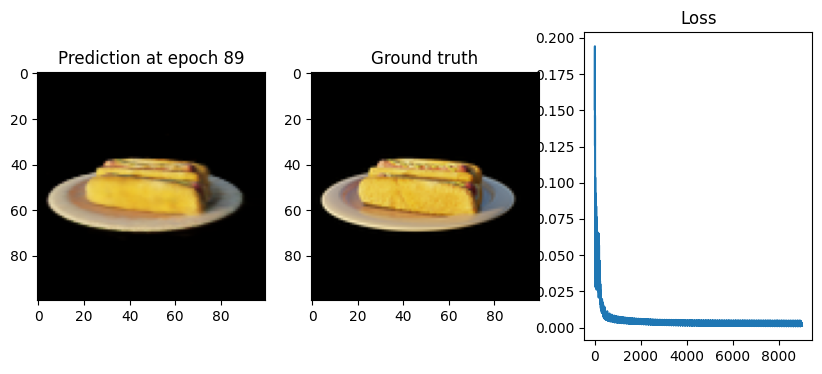

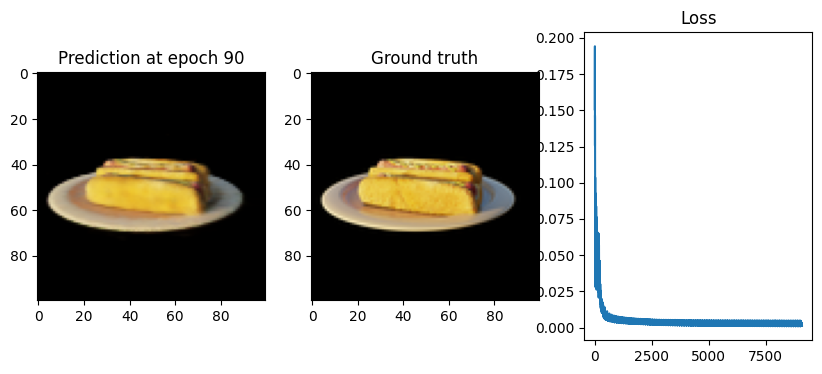

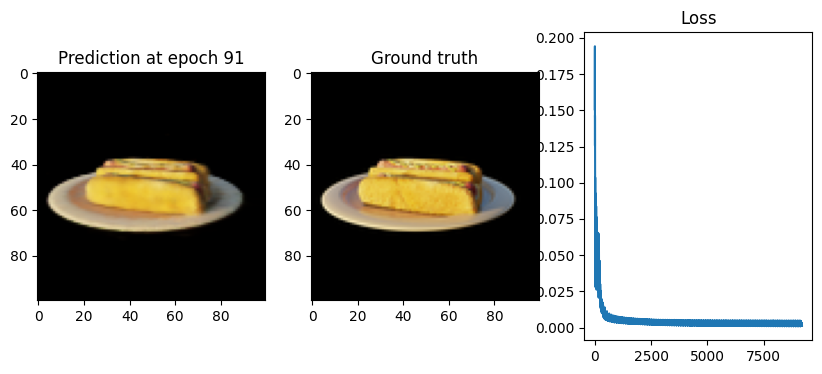

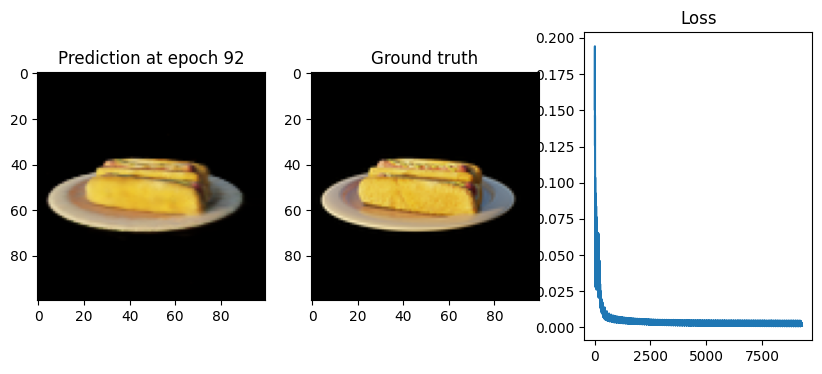

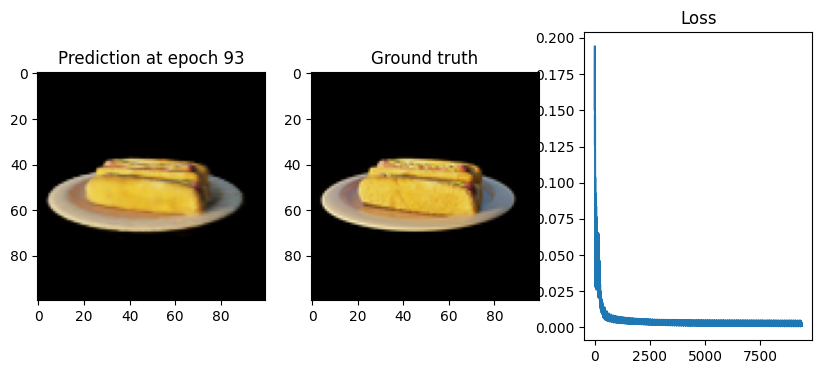

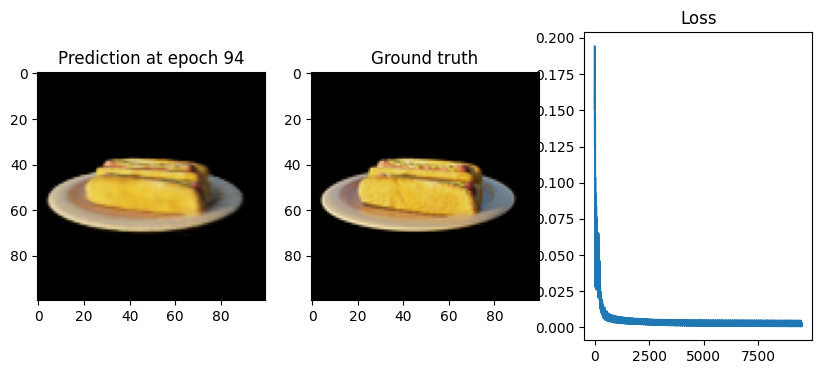

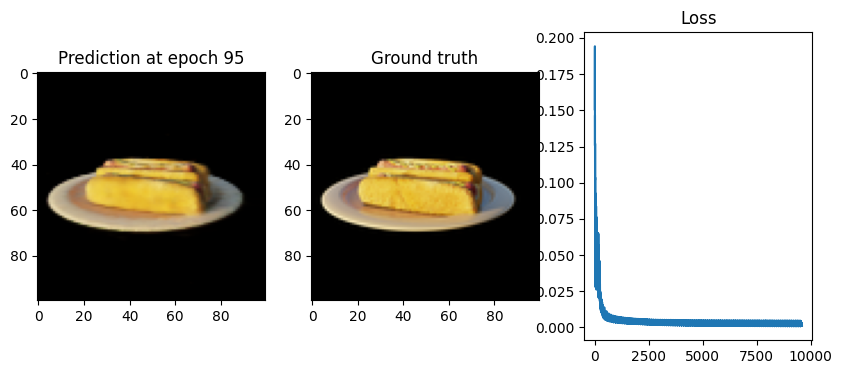

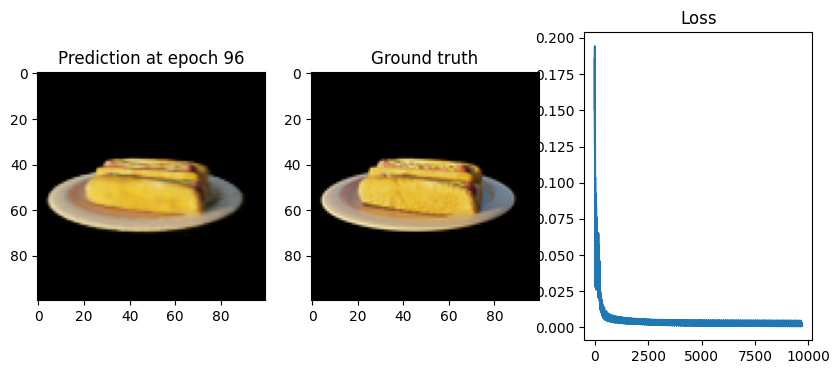

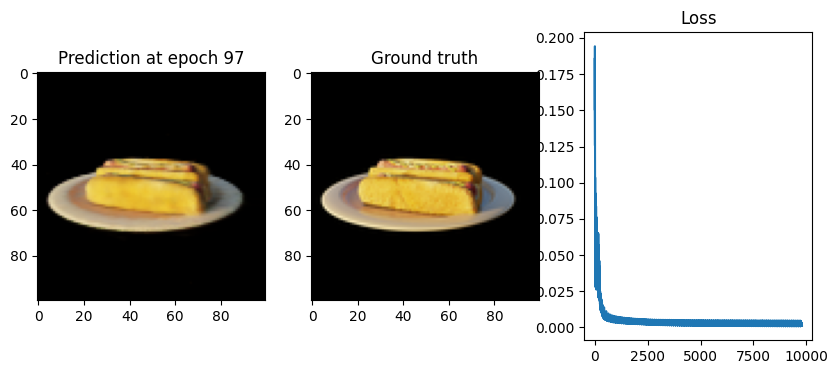

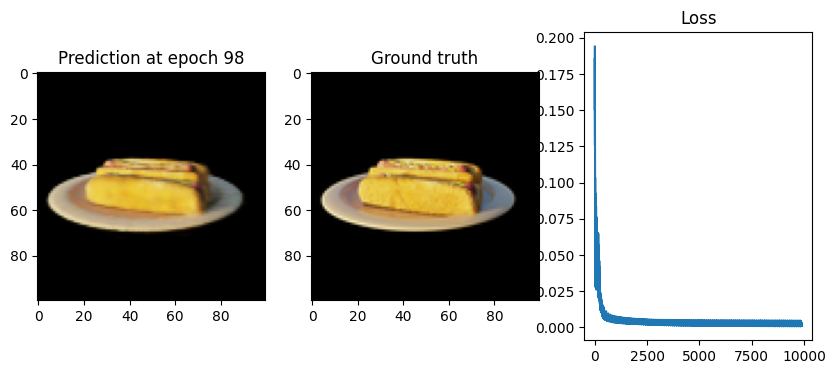

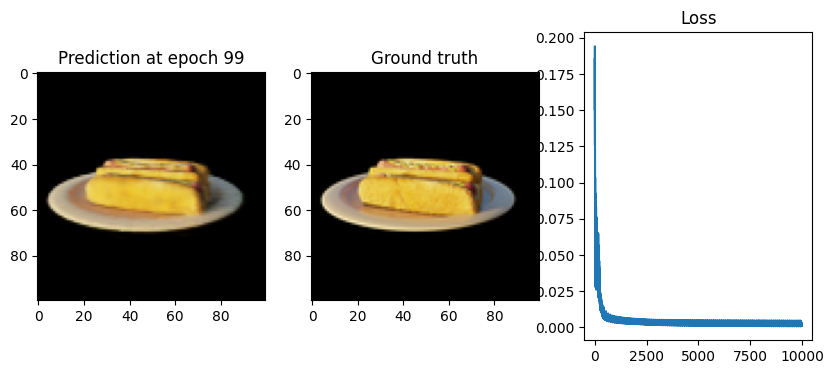

In [ ]:
# ------------------------ TRAINING LOOP ------------------------

model.train()
for epoch in range(epochs):
    for i, dat in enumerate(dataset):
        target_image, target_pose = dat
        target_image = torch.Tensor(target_image).to(device)
        target_pose = torch.Tensor(target_pose).to(device)
        rgb_predicted = nerf.run_one_iter_of_tinynerf(model, height, width, focal_length,
                                                 target_pose, near_thresh,
                                                 far_thresh, depth_samples_per_ray,
                                                 encode, nerf.get_minibatches)
        loss = torch.nn.functional.mse_loss(rgb_predicted, target_image)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
        
    # Now we compare the prediction of NeRF at the test-pose vs. the ground truth
    rgb_predicted = nerf.nerf_prediction(model, height, width, focal_length,
                                            testpose, near_thresh,
                                            far_thresh, depth_samples_per_ray,
                                            encode, nerf.get_minibatches)
    plt.figure(figsize=(10, 4))
    plt.subplot(131)
    plt.imshow(rgb_predicted.detach().cpu().numpy())
    plt.title(f"Prediction at epoch {epoch}")
    plt.subplot(132)
    plt.imshow(testimg.detach().cpu().numpy())
    plt.title("Ground truth")
    plt.subplot(133)
    plt.plot(losses)
    plt.title("Loss")
    
    plt.show()

## Save / load the model

In [ ]:
torch.save(model.state_dict(), "checkpoints/hotdog.pt")

In [ ]:
model = nerf.TinyNerfModel().to(device)
model.load_state_dict(torch.load("checkpoints/hotdog.pt"))
model.eval()

TinyNerfModel(
  (layer1): Linear(in_features=39, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=64, bias=True)
  (layer4): Linear(in_features=64, out_features=32, bias=True)
  (layer5): Linear(in_features=32, out_features=4, bias=True)
)

## Render novel views using a trained NeRF

### sample new views
* our radius (how far we are away we position the camera ) is sampled from $\mathcal{U}[r-1, r+1]$


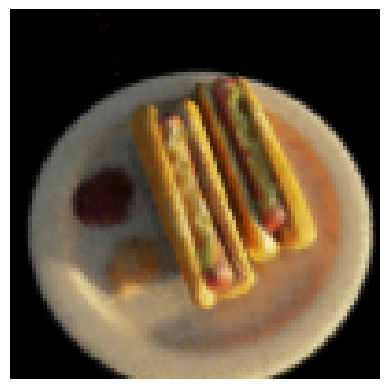

In [ ]:
UP = torch.tensor([0.,0.,1.]).unsqueeze(dim=0).to(device)

def get_new_pose(center, radius):
    """
    generates a new pose / perspective for the NeRF model
    """
    rot = random_rotation().to(device)
    unit_x = torch.tensor([1.,0.,0.]).to(device)
    new_t = center + radius*(rot @ unit_x)

    new_t[2] = torch.abs(new_t[2])
    cam_rot = look_at_rotation(at=new_t.unsqueeze(dim=0), 
                               camera_position=center.unsqueeze(dim=0),up=UP) #tform_cam2world[0, :3, :3]#

    #cam_rot = torch.transpose(cam_rot, 1,2)
    transform = torch.zeros((4,4))#.to(device)
    
    transform[:3, :3] = cam_rot
    transform[:3, 3] = new_t
    transform[3, 3] = 1
    #print(look_at_rotation(center))
    return transform

depth_samples_per_ray = 240

r = torch.tensor(np.random.uniform(radius.item()-1, radius.item()+1)).to(device)
near_thresh, fat_thresh = get_thresholds(r)

new_pose = get_new_pose(center, r).to(device)
predicted = nerf.nerf_prediction(model, height, width, focal_length, new_pose,
                             near_thresh, far_thresh, depth_samples_per_ray,
                             encode, nerf.get_minibatches)

show(predicted.cpu())

## Render new dataset

To successfully train our generative model, we generate a temporary dataset $\hat{\mathcal{T}}$. 

In [ ]:
num_encoding_functions = 6
encode = lambda x: nerf.positional_encoding(x, num_encoding_functions=num_encoding_functions)
depth_samples_per_ray = 240

poses = []
images = []
n_images = 30000
n_dataset = 10000

path = "data/hotdog_data/generated_hot_dog"
dataset = NeRF_Dataset()

for i in range(n_images):
    r = torch.tensor(np.random.uniform(radius.item()-1, radius.item()+1)).to(device)
    near_thresh, fat_thresh = get_thresholds(r)
    new_pose = get_new_pose(center, r).to(device)
    predicted = nerf.nerf_prediction(model, height, width, focal_length, new_pose,
                                near_thresh, far_thresh, depth_samples_per_ray,
                                encode, nerf.get_minibatches).cpu().detach().numpy()
    poses.append(new_pose.cpu().detach().numpy())
    images.append(predicted)
    
    del predicted
    del new_pose
    if i%1000==0:
        print("at iteration ", i)
        
    if (i+1) % n_dataset == 0 and i>0:
        # new now save the temporary dataset, since we have reached max capacity
        pth = os.path.splitext(path)
        filename = pth[-2] + str((i+1)//n_dataset)+ pth[-1]

        print("saving file with %s frames to %s" %(n_dataset, filename))
        poses_ = np.array(poses)
        images_ = np.array(images)

        dataset.pth = filename
        dataset.images = images_
        dataset.poses = poses_
        dataset.focal_length = np.array(focal_length.cpu().detach().numpy())
        dataset.save()
        # now we reset every variable and create a new dataset

        poses = []
        images = []
        dataset = NeRF_Dataset()

at iteration  0
at iteration  1000
at iteration  2000
at iteration  3000
at iteration  4000
at iteration  5000
at iteration  6000
at iteration  7000
at iteration  8000
at iteration  9000
saving file with 10000 frames to data/hotdog_data/generated_hot_dog1
at iteration  10000
at iteration  11000
at iteration  12000
at iteration  13000
at iteration  14000
at iteration  15000
at iteration  16000
at iteration  17000
at iteration  18000
at iteration  19000
saving file with 10000 frames to data/hotdog_data/generated_hot_dog2
at iteration  20000
at iteration  21000
at iteration  22000
at iteration  23000
at iteration  24000
at iteration  25000
at iteration  26000
at iteration  27000
at iteration  28000
at iteration  29000
saving file with 10000 frames to data/hotdog_data/generated_hot_dog3
